# Analyzing asylum denial rates by immigration court
**Julia Ingram / CBS News based on analysis by Joe Yerardi / Philadelphia Inquirer**

This notebook answers several questions about asylum outcomes using data from TRAC.

In [1]:
import pandas as pd
import os

## Import data

Source: `trac_asylum_scraper` outputs in `data/`

In [2]:
# Function to load each CSV and split fymon into separate year and month columns
def load(filename, group_col=None):
    df = pd.read_csv(f"data/exported/{filename}")
    df["year"]  = df["fymon"].str[:4].astype(int)
    df["month"] = df["fymon"].str[5:].astype(int)
    cols = ["court"]
    if group_col:
        cols.append(group_col)
    cols += ["year", "month", "total", "granted", "denied", "other"]
    return df[cols]

total_by_month          = load("master_totals.csv")
custody_by_month        = load("master_custody.csv",        group_col="custody_status")
language_by_month       = load("master_language.csv",       group_col="language")
representation_by_month = load("master_representation.csv", group_col="representation")

## Q1: Overall denial rates

In [3]:
# Helper function to summarize the total granted and denied for a given court or set of courts
def summarize_court(df, court_label):
    c = df[df["court"] == court_label]
    total   = c["total"].sum()
    granted = c["granted"].sum()
    effective_denied = c["denied"].sum() + c["other"].sum()
    return pd.Series({
        "total_cases":    total,
        "total_granted":  granted,
        "total_denied":   effective_denied,
        "pct_granted":    granted / total,
        "pct_denied":     effective_denied / total,
    })
asylum_total = pd.DataFrame({
    "Detroit": summarize_court(total_by_month, "Detroit"),
    "United States": summarize_court(total_by_month, "United States"),
}).T

asylum_total

,total_cases,total_granted,total_denied,pct_granted,pct_denied
Detroit,10902.0,3102.0,7800.0,0.284535,0.715465
United States,1030377.0,385690.0,644687.0,0.374319,0.625681


## Q2: Denial rates by presidential administration

In [4]:
# Map each month to the president who was in office
# Assigns January of the transition year to the outgoing president
def assign_president(row):
    y, m = row["year"], row["month"]
    if   (y < 2001) or (y == 2001 and m == 1):  return "Other"    # Clinton / pre-data
    elif (y < 2009) or (y == 2009 and m == 1):  return "Bush"
    elif (y < 2017) or (y == 2017 and m == 1):  return "Obama"
    elif (y < 2021) or (y == 2021 and m == 1):  return "Trump I"
    elif (y < 2025) or (y == 2025 and m == 1):  return "Biden"
    else:                                         return "Trump II"

PRESIDENT_ORDER = ["Bush", "Obama", "Trump I", "Biden", "Trump II"]

asylum_by_president = (
    total_by_month
    .assign(president=lambda d: d.apply(assign_president, axis=1))
    .query("president != 'Other'")
    .groupby(["president", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="president", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
    .reindex(PRESIDENT_ORDER)
)

asylum_by_president.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_by_president.columns]
asylum_by_president


,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
president,,,,,,
Bush,3118.0,139133.0,0.720092,0.591097,4330.0,235381.0
Obama,1304.0,84479.0,0.740488,0.503268,1761.0,167861.0
Trump I,888.0,141342.0,0.745592,0.690170,1191.0,204793.0
Biden,1576.0,145304.0,0.631410,0.557821,2496.0,260485.0
Trump II,775.0,129623.0,0.829764,0.842726,934.0,153814.0


**Note:** The asylum denial rates in Detroit Immigration Court were almost exactly the same across the Bush, Obama and first Trump administrations. Under Biden, the rates went down (more people were granted asylum), but under Trump II so far, the denial rate is higher.

## Q3: Biden's final year vs. Trump's second term so far (2024 vs 2025)

In [5]:
asylum_biden_vs_trump = (
    total_by_month
    .query("year >= 2024")
    .assign(president=lambda d: d["year"].map({2024: "Biden", 2025: "Trump"}))
    .dropna(subset=["president"])
    .groupby(["president", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="president", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
    .reindex(["Biden", "Trump"])
)

asylum_biden_vs_trump.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_biden_vs_trump.columns]
asylum_biden_vs_trump

,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
president,,,,,,
Biden,509.0,49364.0,0.646760,0.592733,787.0,83282.0
Trump,650.0,102663.0,0.787879,0.804374,825.0,127631.0


**The asylum denial rate has jumped 14 percentage points from the final year of the Biden administration to the first year of the Trump administration.**

## Q4: Monthly denial rates since Jan 2024

In [6]:
asylum_by_month_recent = (
    total_by_month
    .query("year >= 2024")
    .assign(month_label=lambda d: d["year"].astype(str) + "-" + d["month"].astype(str).str.zfill(2))
    .groupby(["month_label", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="month_label", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
    .sort_index()
)

asylum_by_month_recent.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_by_month_recent.columns]
asylum_by_month_recent

,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
month_label,,,,,,
2024-01,70.0,3425.0,0.843373,0.530186,83.0,6460.0
2024-02,43.0,3449.0,0.544304,0.520211,79.0,6630.0
2024-03,35.0,3730.0,0.514706,0.533162,68.0,6996.0
2024-04,45.0,4124.0,0.542169,0.558429,83.0,7385.0
2024-05,60.0,4328.0,0.594059,0.566715,101.0,7637.0
2024-06,23.0,3621.0,0.589744,0.565516,39.0,6403.0
2024-07,68.0,4092.0,0.781609,0.579275,87.0,7064.0
2024-08,25.0,4500.0,0.735294,0.628404,34.0,7161.0
2024-09,21.0,4246.0,0.552632,0.643723,38.0,6596.0


In [28]:
#export to csv
asylum_by_month_recent.to_csv('data/asylum_by_month_recent.csv')


**Despite ranging from 63-80% during most of the first year of Trump II, since October 2025, the asylum denial rate in Detroit immigration court is nearly 100%.**

**During that period, 290 cases denied out of a total of 310.**

## Q5: Denial rates by custody status

In [7]:
asylum_by_custody = (
    custody_by_month
    .groupby(["custody_status", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="custody_status", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
)

asylum_by_custody.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_by_custody.columns]
asylum_by_custody

,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
custody_status,,,,,,
detained,1457.0,119401.0,0.912907,0.843245,1596.0,141597.0
never_detained,5383.0,424635.0,0.681220,0.593511,7902.0,715463.0
not_known,NaN,47.0,NaN,0.573171,NaN,82.0
released,960.0,100604.0,0.683761,0.580737,1404.0,173235.0


**Detroit immigration court has been even harsher to detained immigrants than the US as a whole 91% asylum denial rate, compared to 84% nationally.**

In [23]:
#But, how has the share of cases of people detained changed over time?
detained_not_detained_by_month = custody_by_month.groupby(['court', 'year', 'custody_status']).agg({
    'total': 'sum'
}).reset_index().pivot_table(index=['year', 'court'], columns='custody_status', values='total').reset_index()

detained_not_detained_by_month_detroit = detained_not_detained_by_month[detained_not_detained_by_month['court'] == 'Detroit']
detained_not_detained_by_month_detroit['detained_rate'] = detained_not_detained_by_month_detroit['detained'] / (detained_not_detained_by_month_detroit['detained'] + detained_not_detained_by_month_detroit['never_detained']  + detained_not_detained_by_month_detroit['released'])

/var/folders/yn/1kz4ntb144195kbxp2lt33tc0000gn/T/ipykernel_81295/2316961700.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detained_not_detained_by_month_detroit['detained_rate'] = detained_not_detained_by_month_detroit['detained'] / (detained_not_detained_by_month_detroit['detained'] + detained_not_detained_by_month_detroit['never_detained']  + detained_not_detained_by_month_detroit['released'])


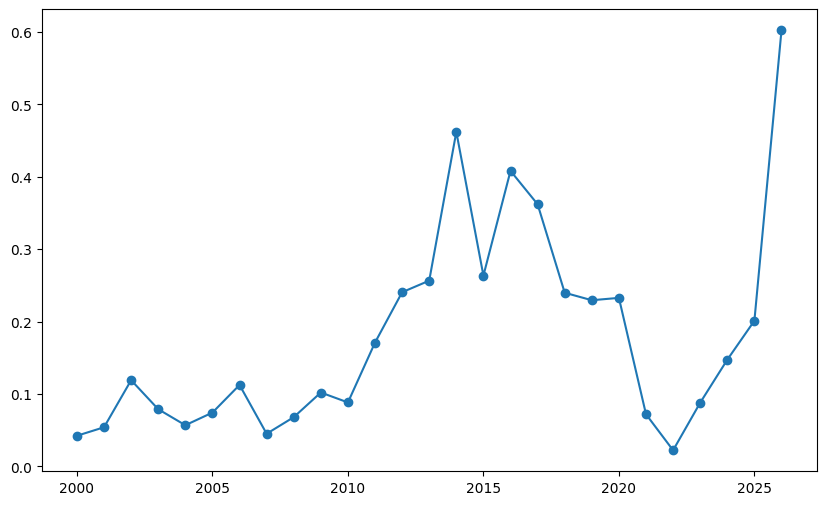

In [24]:
#visualise it
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(detained_not_detained_by_month_detroit['year'], detained_not_detained_by_month_detroit['detained_rate'], marker='o')

In [25]:
#output as csv
detained_not_detained_by_month_detroit.to_csv('data/detained_not_detained_by_month_detroit.csv', index=False)

## Q6: Denial rates by language spoken

In [26]:
asylum_by_language = (
    language_by_month
    .groupby(["language", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="language", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
)

asylum_by_language.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_by_language.columns]
asylum_by_language

,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
language,,,,,,
english,739.0,46664.0,0.666366,0.575829,1109.0,81038.0
non_english,7061.0,598023.0,0.721025,0.629936,9793.0,949339.0
total,7800.0,644687.0,0.715465,0.625681,10902.0,1030377.0


**Non-English speakers were more likely to be denied asylum as well.**

## Q7: Denial rates by access to legal representation

In [27]:
asylum_by_representation = (
    representation_by_month
    .groupby(["representation", "court"])
    .agg(total=("total", "sum"), denied=("denied", "sum"), other=("other", "sum"))
    .reset_index()
    .assign(effective_denied=lambda d: d["denied"] + d["other"],
            pct_denied=lambda d: (d["denied"] + d["other"]) / d["total"])
    .pivot_table(index="representation", columns="court",
                 values=["total", "effective_denied", "pct_denied"])
)

asylum_by_representation.columns = [f"{col[1].lower().replace(' ', '_')}_{col[0]}" for col in asylum_by_representation.columns]
asylum_by_representation

,detroit_effective_denied,united_states_effective_denied,detroit_pct_denied,united_states_pct_denied,detroit_total,united_states_total
representation,,,,,,
not_represented,1879.0,174026.0,0.917480,0.859065,2048.0,202576.0
represented,5921.0,470661.0,0.668737,0.568568,8854.0,827801.0


**Having legal representation makes it way more likely you'll be granted asylum: 1 in 3 chance vs. 1 in 10 chance**